# Minimal Example: TMAP versus blackbody for an example binary

In this example script, we'll reproduce Figure 7 from the v2.5 release paper ([Jones et al. 2026](http://phoebe-project.org/publications/2026Jones+)).

Let's first make sure we have the latest version of PHOEBE 2.5 installed (uncomment this line if running in an online notebook session such as colab).

In [1]:
#!pip install -I "phoebe>=2.5"

In [1]:
import numpy as np
import phoebe
from phoebe import u,c
import matplotlib.pyplot as plt
%matplotlib inline
from corner import corner
from matplotlib import gridspec
from matplotlib import rcParams
import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
rcParams["font.size"] = 18
#rcParams["text.latex.preamble"] = r"\usepackage{cmbright}"
rcParams["savefig.dpi"] = 100
from scipy.optimize import minimize
from phoebe.atmospheres import models
from phoebe.atmospheres.passbands import InterpQuery


In [2]:
def logg(M,R):
	g=c.G*M*u.solMass/((R*u.solRad)**2)
	logg=np.log10(g.to(u.cm/u.s**2).value)
	return logg
	
def radius(logg,M):
	g=(10**logg)*u.cm/u.s**2
	R=np.sqrt(c.G*M*u.solMass/g).to(u.m)
	return R.to(u.solRad).value
	
def mass(logg,R):
	g=(10**logg)*u.cm/u.s**2
	M=(g * (R*u.solRad)**2)/c.G
	return M.to(u.solMass).value

In [3]:
def MRR(M):
    R = 0.438*M*M + 0.479*M + 0.075
    return R

def MLR(M):
    if M <= 0.45:
        L=10**(2.028*np.log10(M) - 0.976)
    elif M <= 0.72:
        L=10**(4.572*np.log10(M) - 0.102)
    elif M <= 1.05:
        L=10**(5.743*np.log10(M) - 0.007)
    elif M <= 2.40:
        L=10**(4.329*np.log10(M) - 0.010)
    return L


def MTR(M):
    L=MLR(M)
    R=MRR(M)*u.solRad
    T=np.sqrt(np.sqrt(L*u.solLum/(4*np.pi*R*R*c.sigma_sb)))
    return T.to(u.K).value

In [4]:
period = 0.333 #days


b=phoebe.default_binary()
b['period@orbit']=period
b.flip_constraint('mass@primary','sma@binary')


b.add_dataset('lc',
              times = np.linspace(0.,1.,300)*period,
              passband = 'SDSS:iprime',
              dataset = 'lc_i',
              overwrite = True)



<ParameterSet: 86 parameters | contexts: figure, dataset, compute, constraint>

In [5]:
b.set_value('gravb_bol', component = 'primary', value = 1)
b['irrad_frac_refl_bol@primary']=0.6


b.set_value_all('pblum_mode','absolute')

for param in b.filter(qualifier='irrad_frac_refl_bol').to_list():
    param._limits=[0, None]
for param in b.filter(qualifier='irrad_frac_lost_bol', context='component').to_list():
    param._limits=[None, 1]



In [6]:
#MMMB track
# Post-AGB, H-burner
# Initial Mass, Final Mass, Number Track Points
#   1.500000     0.559500      301
# Surface composition:
#     H      He        C        N        O
#  .706     .275     .842E-02 .109E-02 .632E-02
#
loghefrac=np.log(0.275/0.706)
mass=0.559510
logg=5.984140
teff=10**5.104764
mass2=0.7
b.set_value_all('atm@primary','tmap_sdO')
b['loghefrac@primary']=loghefrac
b['mass@primary']=mass
b['requiv@primary']=radius(logg,mass)
b['teff@primary']=teff
b['q']=mass2/mass
b['requiv@secondary']=MRR(mass2)
b['teff@secondary']=MTR(mass2)




b['irrad_frac_refl_bol@secondary']=0.6
b.run_compute(model='tmap',overwrite=True)


100%|████████████████████████████████████████| 300/300 [00:01<00:00, 215.71it/s]


<ParameterSet: 3 parameters | qualifiers: fluxes, comments, times>

In [7]:
b['atm@primary']='blackbody'
pb=phoebe.get_passband('SDSS:iprime')
b['ld_mode@primary']='manual'
b['ld_func@primary']='linear'
query_pts=np.ascontiguousarray([np.array([teff,logg,loghefrac]).T])
query_table=InterpQuery(cols=['teffs','loggs','loghefracs'],pts=np.c_[query_pts])
ldcoeff=pb.interpolate_ldcoeffs(query=query_table,ldatm=models.TMAPsdOModelAtmosphere,ld_func='linear').get_interpolated_values()
b['ld_coeffs@primary']=ldcoeff[0]


# pb=phoebe.get_passband('Bolometric:900-40000')
b['ld_mode_bol@primary']='manual'
b['ld_func_bol@primary']='linear'
b['ld_coeffs_bol@primary']=[0]

b.run_compute(model='bb',overwrite=True)

100%|████████████████████████████████████████| 300/300 [00:01<00:00, 225.49it/s]


<ParameterSet: 3 parameters | qualifiers: fluxes, comments, times>

In [8]:
bbteff=0.74*teff
b['teff@primary']=bbteff
b['irrad_frac_refl_bol@secondary']=0.6
b.run_compute(model='bbalt',overwrite=True)

100%|████████████████████████████████████████| 300/300 [00:01<00:00, 223.54it/s]


<ParameterSet: 3 parameters | qualifiers: fluxes, comments, times>

In [9]:
b['irrad_frac_refl_bol@secondary']=2.0
b.run_compute(model='bbalt2',overwrite=True)

100%|████████████████████████████████████████| 300/300 [00:01<00:00, 223.47it/s]


<ParameterSet: 3 parameters | qualifiers: fluxes, comments, times>

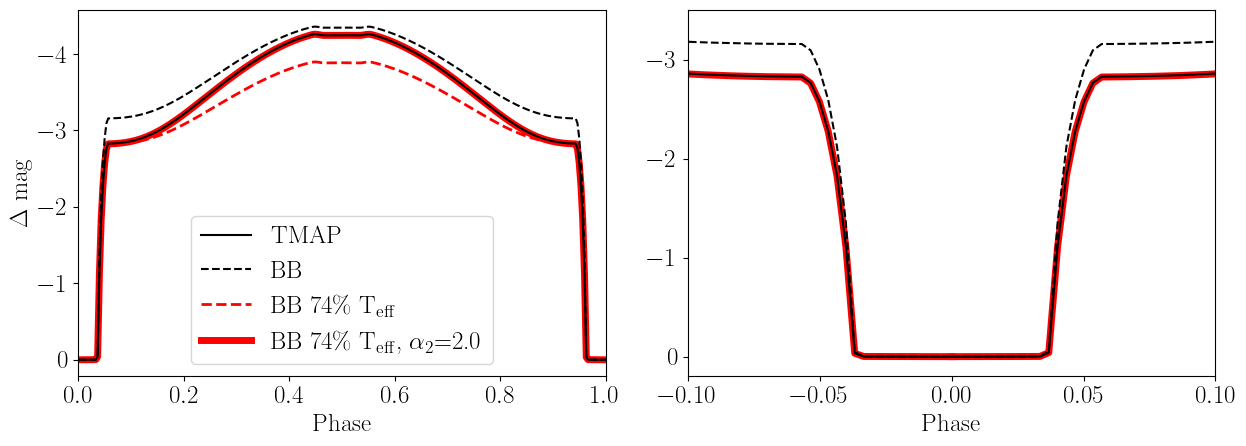

In [10]:
tmapmodel=-2.5*np.log10(b['fluxes@lc_i@tmap@model'].value)
bbmodel=-2.5*np.log10(b['fluxes@lc_i@bb@model'].value)
bbaltmodel=-2.5*np.log10(b['fluxes@lc_i@bbalt@model'].value)
bbalt2model=-2.5*np.log10(b['fluxes@lc_i@bbalt2@model'].value)

bbmodel=bbmodel-np.max(tmapmodel)
bbaltmodel=bbaltmodel-np.max(tmapmodel)
bbalt2model=bbalt2model-np.max(tmapmodel)
tmapmodel=tmapmodel-np.max(tmapmodel)

plt.figure(figsize=(12.8,4.8))
gs=gridspec.GridSpec(1,2)
times = np.linspace(0.,1.,300)


ax=plt.subplot(gs[0,0])
ax.plot(times,tmapmodel,color='k',label='TMAP')
ax.plot(times,bbmodel,color='k',ls='--',label='BB')
ax.plot(times,bbaltmodel,color='r',ls='--',lw=2,label=r'BB 74\% T$_\mathrm{eff}$',zorder=-5)
ax.plot(times,bbalt2model,color='r',lw=5,label=r'BB 74\% T$_\mathrm{eff}$, $\alpha_2$=2.0',zorder=-5)
ax.legend()
ax.set_xlim([0,1])
ax.set_xlabel("Phase")
ax.set_ylabel(r"$\Delta$ mag")
ax.invert_yaxis()

ax1=plt.subplot(gs[0,1])
ax1.plot(times,tmapmodel,color='k',label='TMAP')
ax1.plot(times,bbmodel,color='k',ls='--',label='BB')
ax1.plot(times,bbaltmodel,color='r',ls='--',lw=2,label=r'BB 74\% T$_\mathrm{eff}$',zorder=-5)
ax1.plot(times,bbalt2model,color='r',lw=5,label=r'BB 74\% T$_\mathrm{eff}$, $\alpha_2$=2.0',zorder=-5)
ax1.plot(times-1,tmapmodel,color='k')
ax1.plot(times-1,bbmodel,color='k',ls='--')
ax1.plot(times-1,bbaltmodel,color='r',ls='--',lw=2,zorder=-5)
ax1.plot(times-1,bbalt2model,color='r',lw=5,zorder=-5)
ax1.set_xlim([-0.1,0.1])
ax1.set_ylim([0.2,-3.5])
ax1.set_xlabel("Phase")
# ax1.legend()

plt.tight_layout()
